
# Import Libraries

In [1]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    Input
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


## Dataset Loading

In [4]:
dataset_path ="C:/Users/Dell/Downloads/archive/lung_colon_image_set"

colon_path = os.path.join(dataset_path, "colon_image_sets")
lung_path = os.path.join(dataset_path, "lung_image_sets")

print("Colon Classes :", os.listdir(colon_path))
print("Lung Classes :", os.listdir(lung_path))

Colon Classes : ['colon_aca', 'colon_n']
Lung Classes : ['lung_aca', 'lung_n', 'lung_scc']


## Count Images

In [5]:
classes = {}

for folder in os.listdir(colon_path):
    folder_path = os.path.join(colon_path, folder)
    classes[folder] = len(os.listdir(folder_path))

for folder in os.listdir(lung_path):
    folder_path = os.path.join(lung_path, folder)
    classes[folder] = len(os.listdir(folder_path))

df = pd.DataFrame(
    list(classes.items()),
    columns=["Class", "Images"]
)

df

,Class,Images
0,colon_aca,5000
1,colon_n,5000
2,lung_aca,5000
3,lung_n,5000
4,lung_scc,5000


## Visualize Dataset

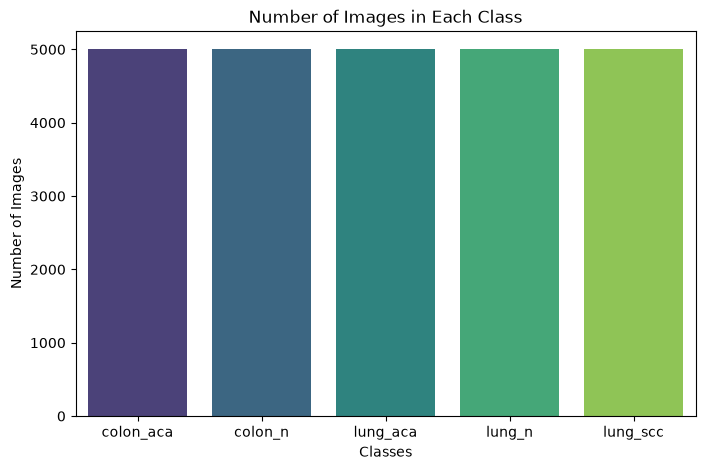

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Class",
    y="Images",
    palette="viridis"
)

plt.title("Number of Images in Each Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

## EDA

2.1 Display Sample Images

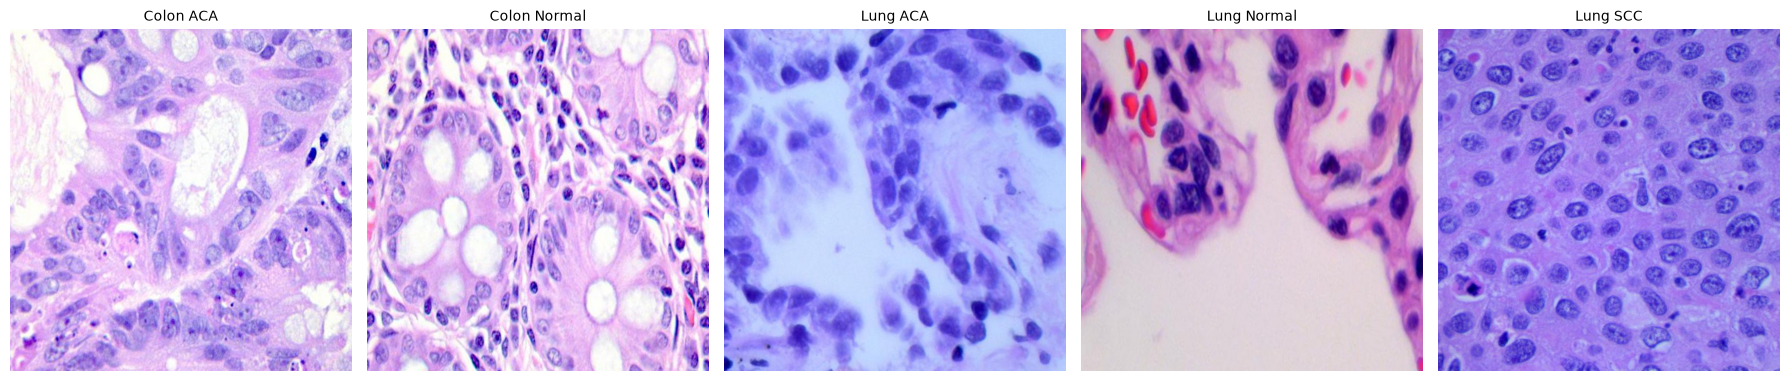

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18,5))

all_classes = [
    os.path.join(colon_path, "colon_aca"),
    os.path.join(colon_path, "colon_n"),
    os.path.join(lung_path, "lung_aca"),
    os.path.join(lung_path, "lung_n"),
    os.path.join(lung_path, "lung_scc")
]

titles = [
    "Colon ACA",
    "Colon Normal",
    "Lung ACA",
    "Lung Normal",
    "Lung SCC"
]

for i, folder in enumerate(all_classes):

    image_name = random.choice(os.listdir(folder))
    image_path = os.path.join(folder, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axes[i].imshow(image)
    axes[i].set_title(titles[i], fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

2.2 Check Image Size

In [8]:
for folder in all_classes:

    image_name = random.choice(os.listdir(folder))
    image_path = os.path.join(folder, image_name)

    image = cv2.imread(image_path)

    print(os.path.basename(folder))
    print("Shape :", image.shape)
    print("-"*40)

colon_aca
Shape : (768, 768, 3)
----------------------------------------
colon_n
Shape : (768, 768, 3)
----------------------------------------
lung_aca
Shape : (768, 768, 3)
----------------------------------------
lung_n
Shape : (768, 768, 3)
----------------------------------------
lung_scc
Shape : (768, 768, 3)
----------------------------------------


2.3 Check Missing / Corrupted Images

In [9]:
corrupted = 0

for folder in all_classes:

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        image = cv2.imread(image_path)

        if image is None:
            corrupted += 1

print("Corrupted Images :", corrupted)

Corrupted Images : 0


2.4 Create DataFrame

In [10]:
paths = []
labels = []

for folder in os.listdir(colon_path):

    folder_path = os.path.join(colon_path, folder)

    for image in os.listdir(folder_path):

        paths.append(os.path.join(folder_path, image))
        labels.append(folder)

for folder in os.listdir(lung_path):

    folder_path = os.path.join(lung_path, folder)

    for image in os.listdir(folder_path):

        paths.append(os.path.join(folder_path, image))
        labels.append(folder)

data = pd.DataFrame({
    "Path": paths,
    "Label": labels
})

data.head()

,Path,Label
0,C:/Users/Dell/Downloads/archive/lung_colon_ima...,colon_aca
1,C:/Users/Dell/Downloads/archive/lung_colon_ima...,colon_aca
2,C:/Users/Dell/Downloads/archive/lung_colon_ima...,colon_aca
3,C:/Users/Dell/Downloads/archive/lung_colon_ima...,colon_aca
4,C:/Users/Dell/Downloads/archive/lung_colon_ima...,colon_aca


2.5 Dataset Information

In [11]:
print("Dataset Shape :", data.shape)
print()

print(data["Label"].value_counts())

Dataset Shape : (25000, 2)

Label
colon_aca    5000
colon_n      5000
lung_aca     5000
lung_n       5000
lung_scc     5000
Name: count, dtype: int64


##  Preprocessing


3.1 Split Dataset

In [12]:
train_df, test_df = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=data["Label"]
)

train_df, valid_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["Label"]
)

print("Training Images :", len(train_df))
print("Validation Images :", len(valid_df))
print("Testing Images :", len(test_df))

Training Images : 16000
Validation Images : 4000
Testing Images : 5000


3.2 Data Preprocessing(Generators)

In [14]:
train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

valid_generator = ImageDataGenerator(
    rescale=1./255
)

test_generator = ImageDataGenerator(
    rescale=1./255
)

In [16]:
train_data = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="Path",
    y_col="Label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

valid_data = valid_generator.flow_from_dataframe(
    dataframe=valid_df,
    x_col="Path",
    y_col="Label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col="Path",
    y_col="Label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 16000 validated image filenames belonging to 5 classes.
Found 4000 validated image filenames belonging to 5 classes.
Found 5000 validated image filenames belonging to 5 classes.


3.3 Visualize Preprocessed Images

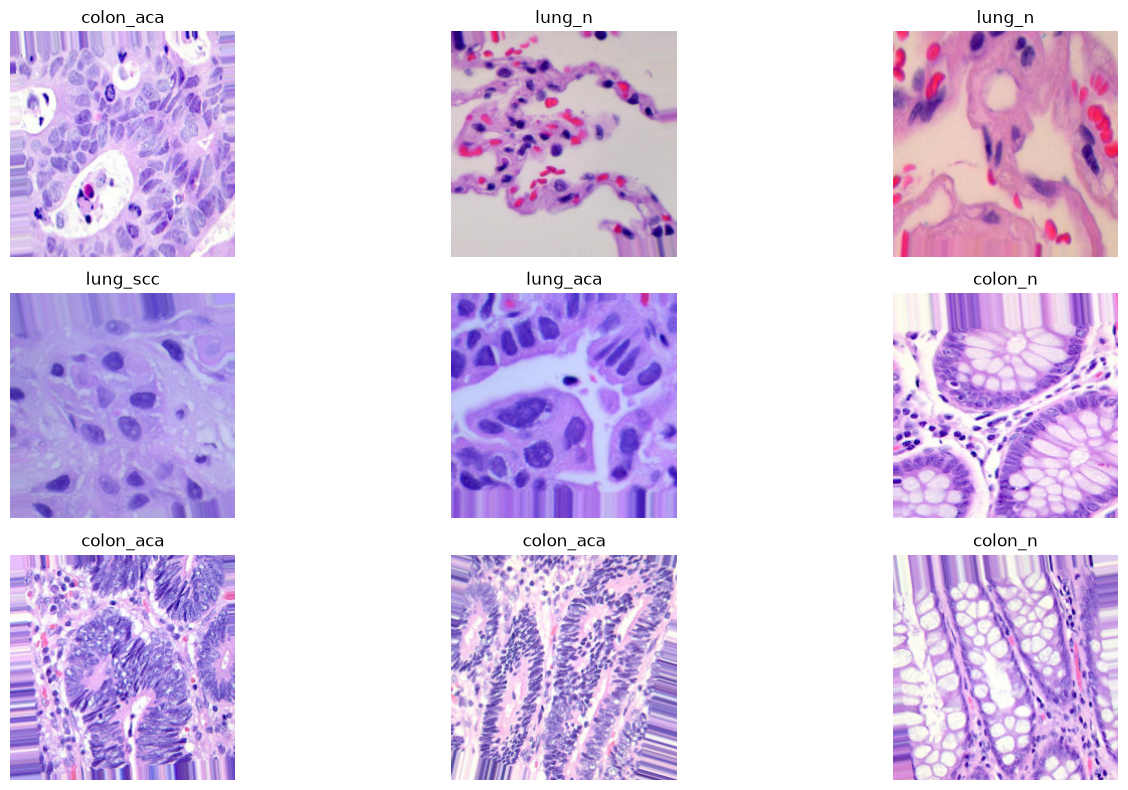

In [17]:
images, labels = next(train_data)

plt.figure(figsize=(15,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(
        list(train_data.class_indices.keys())[np.argmax(labels[i])]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Build CNN Model

In [18]:
model = Sequential([

    Input(shape=(224, 224, 3)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(5, activation='softmax')

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,397,829 (74.00 MB)

 Trainable params: 19,396,869 (73.99 MB)

 Non-trainable params: 960 (3.75 KB)

4.1 Compile Model

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Success")

Model Compiled Success


4.2 Callbacks

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

4.3 Train CNN Model

In [21]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7721 - loss: 2.5439
Epoch 1: val_accuracy improved from None to 0.85900, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 1268s 3s/step - accuracy: 0.7721 - loss: 2.5439 - val_accuracy: 0.8590 - val_loss: 0.3602 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8651 - loss: 0.4508
Epoch 2: val_accuracy did not improve from 0.85900
500/500 ━━━━━━━━━━━━━━━━━━━━ 1078s 2s/step - accuracy: 0.8651 - loss: 0.4508 - val_accuracy: 0.8390 - val_loss: 0.4454 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8870 - loss: 0.3795
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 3: val_accuracy did not improve from 0.85900
500/500 ━━━━━━━━━━━━━━━━━━━━ 798s 2s/step - accuracy: 0.8870 - loss: 0.3795 - val_accuracy: 0.5913 - val_loss: 3.9563 - learning_rate: 0.0010

4.4 Save Model


In [22]:
model.save("lung_colon_cancer_model.keras")

print("Model Saved Success")

Model Saved Success


4.5 Plot Training History

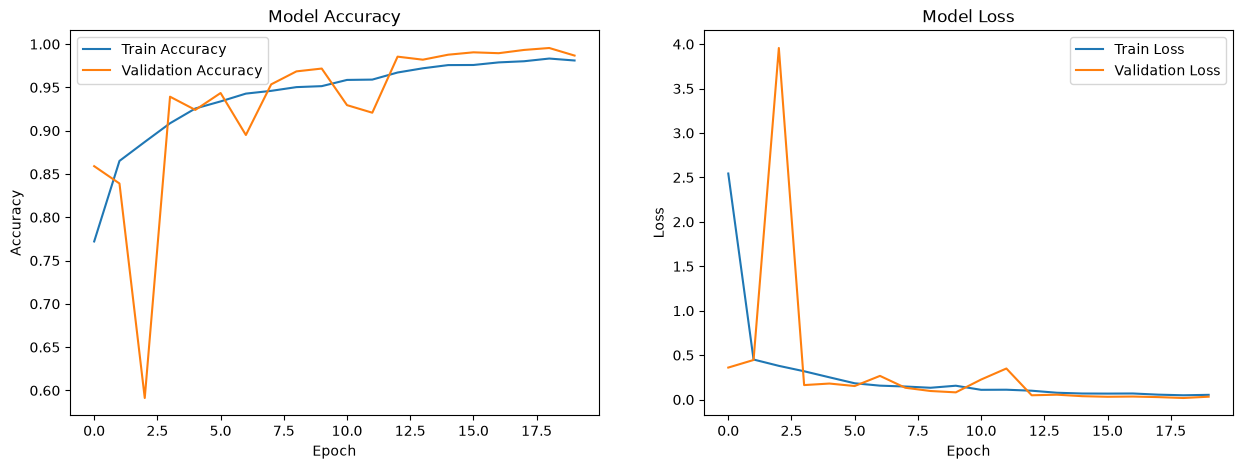

In [23]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

4.6  Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


loss, accuracy = model.evaluate(test_data, verbose=1)
predictions = model.predict(test_data, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("="*50)
print(f"Test Loss      : {loss:.4f}")
print(f"Test Accuracy  : {accuracy*100:.2f}%")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")
print("="*50)

157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 318ms/step - accuracy: 0.9944 - loss: 0.0183
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 335ms/step
Test Loss      : 0.0183
Test Accuracy  : 99.44%
Precision      : 0.9944
Recall         : 0.9944
F1-Score       : 0.9944


4.7 Model Predictions

In [25]:
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_names = list(test_data.class_indices.keys())

157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 291ms/step


4.8 Classification Report

In [26]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

   colon_aca       1.00      1.00      1.00      1000
     colon_n       1.00      1.00      1.00      1000
    lung_aca       0.99      0.98      0.99      1000
      lung_n       1.00      1.00      1.00      1000
    lung_scc       0.99      0.99      0.99      1000

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



4.9 Confusion Matrix

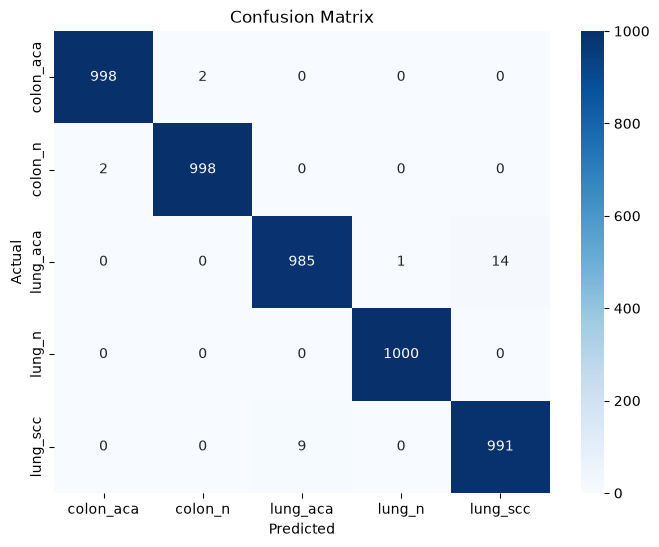

In [27]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

4.10 ROC Curve & AUC Score

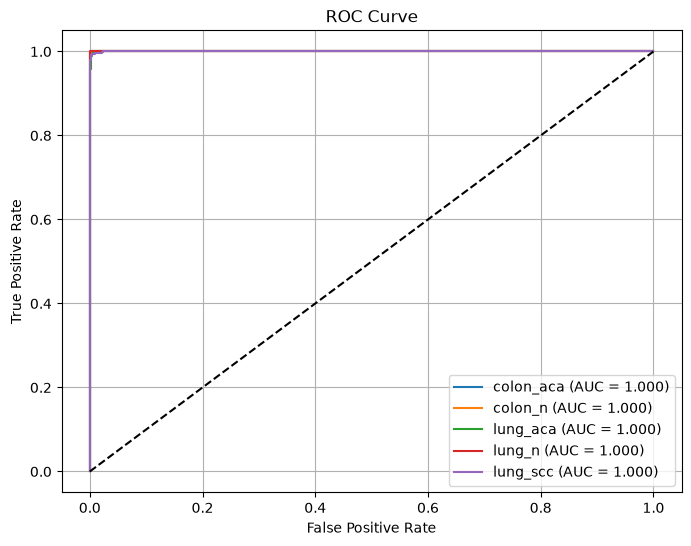

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


y_true_bin = label_binarize(
    y_true,
    classes=range(len(class_names))
)

plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        predictions[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()

4.11 Predict Single Image

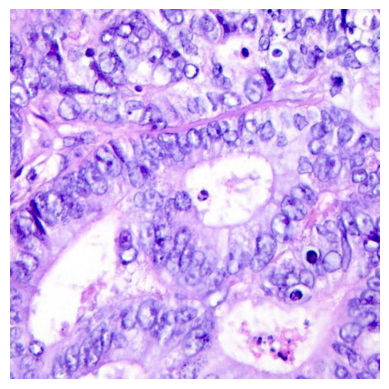

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Prediction : colon_aca


In [48]:
image_path = test_df.iloc[0]["Path"]
image = cv2.imread("C:\\Users\\Dell\\Desktop\\la.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

img = cv2.resize(image, (224,224))
img = img.astype("float32") / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

predicted_label = class_names[np.argmax(prediction)]

print("Prediction :", predicted_label)

In [37]:
import json

classes = list(train_data.class_indices.keys())

with open("classes.json","w") as f:
    json.dump(classes,f)

print(classes)

['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


Save Final Model

In [49]:
model.save("lung_colon_cancer_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


## Streamlit App